# Tutorial_8_TP_Profile_Type_4

This tutorial shows how to run a retrieval using the Zhang+2023 TP profile and plot the generated TP profile. It also shows how to adjust the priors.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from collections import namedtuple
import settings
import utils
import test_module
import pickle as pickle
import TPmod
from specops import proc_spec
from IPython.display import display
%matplotlib inline

# 1. Setup basic retrieval parameters

The Zhang+2023 profile type can be used by specifying `ptype=4`. This uses the default parameterisation with `num_coarsePress = 6` layers and `num_finePress = 100`. This default parameterisation also uses the default priors specified in Zhang+2023.

In [ ]:
# instrument
wavelength_range=[1,2.49]
ndata=1
Rfile='examples/example_data/G570D_R_file.txt'
obspec = np.asfortranarray(np.loadtxt("examples/example_data/G570D_2MHcalib.dat",dtype='d',unpack='true')) # G570D_2MassJcalib.dat

## gas
chemeq=0
# gaslist = ['h2o','co','tio','vo','crh','feh','na','k']
gaslist = ['h2o','ch4']
gastype_list=['U','U']

# PT structure
ptype=4
num_coarsePress = 6

## clouds
cloudpath='/Users/maddie/Documents/Clouds_V2/'
do_clouds=0
npatches=1

# ModelConfig:
do_fudge=1
samplemode='mcmc'


instrument_instance = utils.Instrument(wavelength_range=wavelength_range, R_file=Rfile,obspec=obspec)
re_params = utils.Retrieval_params(samplemode=samplemode,
                                   chemeq=chemeq,
                                   gaslist=gaslist,
                                   gastype_list=gastype_list,
                                   do_fudge=do_fudge,
                                   ptype=ptype,
                                   num_coarsePress=num_coarsePress,
                                   do_clouds=do_clouds,
                                   npatches=npatches,
                                   instrument=instrument_instance,
                                   fwhm=None)
model_config_instance = utils.ModelConfig(samplemode,do_fudge,cloudpath=cloudpath)
io_config_instance = utils.IOConfig()

io_config_instance.outdir="/Users/maddie/Documents/development/brewster_v2/examples/G570D_emcee/"
io_config_instance.runname='V2_G570D_test'
io_config_instance.update_dictionary()

model_config_instance.dist= 5.84
model_config_instance.xlist ='data/gaslistRox.dat'
model_config_instance.xpath ='/Users/maddie/Documents/Linelist_basic/'
model_config_instance.do_bff=1
model_config_instance.malk=0
model_config_instance.ch4=0
model_config_instance.niter=300
model_config_instance.update_dictionary()

Generate arguments instance and print parameters

In [3]:
args_instance = utils.ArgsGen(re_params,model_config_instance,instrument_instance,obspec)
settings.init(args_instance)
settings.cia = args_instance.cia
settings.linelist= utils.get_opacities(args_instance.gaslist,args_instance.w1,args_instance.w2,args_instance.press,args_instance.xpath,args_instance.xlist,args_instance.malk)
settings.cloudata = args_instance.cloudata

args_instance=settings.runargs
all_params,all_params_values =utils.get_all_parametres(re_params.dictionary)
print(all_params)
print(all_params_values)

['h2o', 'ch4', 'logg', 'r2d2', 'dlambda', 'tolerance_parameter_1', 'Tbottom', 'dTdP1', 'dTdP2', 'dTdP3', 'dTdP4', 'dTdP5', 'dTdP6']
[None, None, None, None, None, None, None, None, None, None, None, None, None]


# 2. Fit gradients from user-specified TP profile.

Load user specified TP profile. Here is an example from a Sonora Diamondback model.

Text(0, 0.5, 'log$_{10}$(P) [bar]')

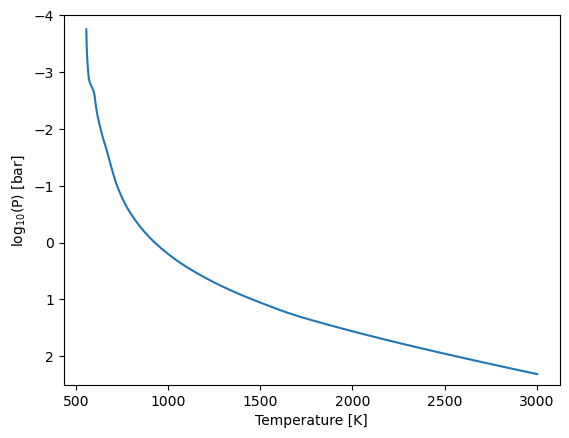

In [4]:
data_db = np.loadtxt('/Users/maddie/Documents/pressure-temperature_profiles/t1400g3160nc_m-0.5_co1.0.pt', skiprows=2, usecols=(1,2))
pressure_db = data_db[:,0]
temperature_db = data_db[:,1]
ln_pressure_db = np.log(pressure_db)
log_pressure_db = np.log10(pressure_db)
ln_temperature_db = np.log(temperature_db)
plt.plot(temperature_db,log_pressure_db)
plt.ylim(2.5,-4)
plt.xlabel('Temperature [K]')
plt.ylabel('log$_{10}$(P) [bar]')

Fit the gradient $d\ln T/ d\ln P$ at each pressure layer, specified by `num_coarsePress`.

0.054695940179701495
0.0835743846050925
0.1291435694631797
0.17630645729989464
0.21868111397330314
0.24968870532835222


Text(0, 0.5, 'ln(T)')

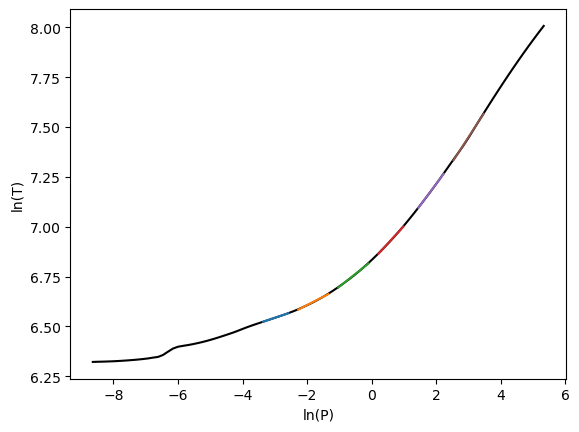

In [5]:
layer_pressures = np.linspace(-3,3,num_coarsePress)
plt.plot(ln_pressure_db,ln_temperature_db,color='k')
dTdP = []
for layer in layer_pressures:
    press = ln_pressure_db[(ln_pressure_db > (layer - 0.5)) & (ln_pressure_db < (layer + 0.5))]
    temp = ln_temperature_db[(ln_pressure_db > (layer - 0.5)) & (ln_pressure_db < (layer + 0.5))]
    coef = np.polyfit(press,temp, 1)
    # plt.plot(press,temp)
    plt.plot(press, coef[0]*press + coef[1])
    print(coef[0])
    dTdP.append(coef[0])
# plt.ylim(4,-5)
plt.xlabel('ln(P)')
plt.ylabel('ln(T)')

Use these fitted values to initialise the priors for the TP profile. The dTdP parameters start from the bottom of the atmosphere (higher pressures)

In [6]:
for i in range(num_coarsePress):
    re_params.dictionary['pt']['params']['dTdP'+str(i+1)]['MC_init_dis'] = ['normal',dTdP[-(i+1)],0.1]

re_params.update_dictionary()

Generate TP profile from specified priors

In [7]:
all_params,all_params_values =utils.get_all_parametres(re_params.dictionary)

if re_params.samplemode=='mcmc':
    
    model_config_instance.ndim=len(all_params)
    model_config_instance.nwalkers=len(all_params)*16

    r2d2 = (71492e3)**2. / (model_config_instance.dist * 3.086e+16)**2.
    re_params.dictionary['refinement_params']['params']['r2d2']['MC_init_dis']=['normal',r2d2,0.1*r2d2]


    def tolerance_parameter_customized_distribution(x):
        return np.log10((np.random.rand(x)* (max(args_instance.obspec[2,:]**2)*(0.1 - 0.01))) + (0.01*min(args_instance.obspec[2,10::3]**2))) 

    for i in range(len(all_params)):
        if all_params[i].startswith('tolerance_parameter'):
            re_params.dictionary['refinement_params']['params'][all_params[i]]['MC_init_dis']=['customized',tolerance_parameter_customized_distribution]

    if model_config_instance.fresh == 0:
        p0=utils.MC_P0_gen(re_params.dictionary,model_config_instance,args_instance)

In [8]:
params_master = namedtuple('params',all_params)
params_instance = params_master(*p0[0,:])
print(params_instance)
gnostics = 0
trimspec, photspec, tauspec,cfunc = test_module.modelspec(params_instance,re_params,args_instance,gnostics)
intemp_keys = list(re_params.dictionary['pt']['params'].keys())
intemp = np.array([getattr(params_instance, key) for key in intemp_keys])

Tprof = TPmod.set_prof(args_instance.proftype, args_instance.coarsePress, args_instance.press,intemp)

params(h2o=np.float64(-3.7651407632241676), ch4=np.float64(-3.8436565642318885), logg=np.float64(4.5641584278082465), r2d2=np.float64(1.4423668969561269e-19), dlambda=np.float64(0.0007281586256952469), tolerance_parameter_1=np.float64(-32.13397662415562), Tbottom=np.float64(5630.513490295329), dTdP1=np.float64(0.29885740364290214), dTdP2=np.float64(0.27907437813520625), dTdP3=np.float64(0.0936115239144806), dTdP4=np.float64(0.20593937044857097), dTdP5=np.float64(0.1902915061414251), dTdP6=np.float64(0.022721955170135685))


Plot TP profile generated from priors

Text(0.5, 0, 'T / K')

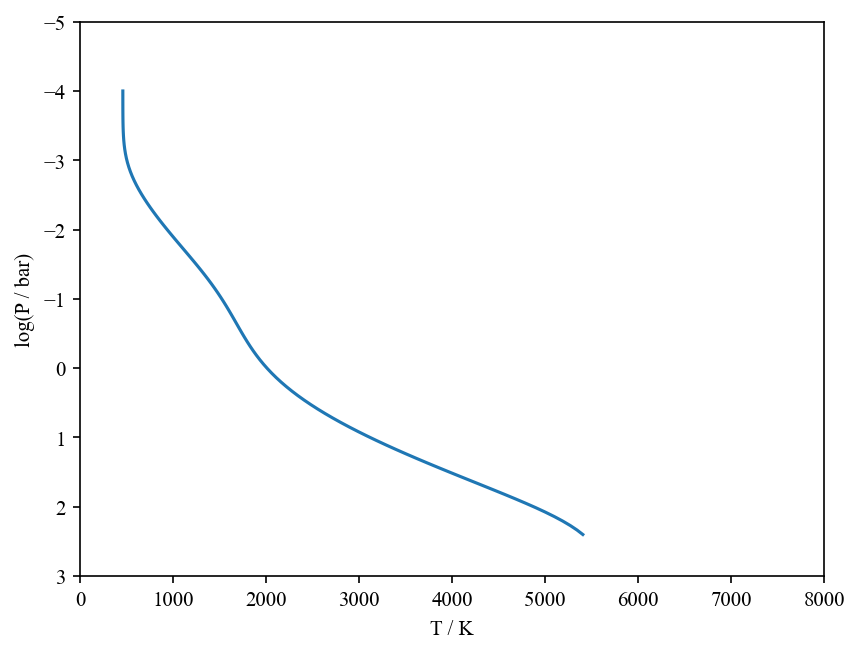

In [9]:
plt.rc('font',family='Times New Roman')
fig=plt.figure(dpi=150)
plt.axis([0., 8000.,3.0,-5.0])

logP = np.log10(args_instance.press)


plt.plot(Tprof,logP,label='proftype=4')

plt.ylabel(r'log(P / bar)')
plt.xlabel('T / K')

# 3. Adjusting the number of grid layers

To change the number of grid layers, the user will have to setup their own priors. Here is an example for a TP profile with 10 layers, and priors specified as in Nasedkin+2025. This can be done by setting `num_coarsePress=10` in `utils.Retrieval_params()`. The setup of the retrieval parameters is similar to above. 


The minimum number of `num_finePress` points is 100. However, the maximum number of layers for the pressure grid is also 100, and is specified in the `sizes_mod.f90` file. If the user desires a finer grid, then this value will also need to be changed, and `brewster` will need to be compiled. This tutorial will focus only on using `num_finePress = 100`, which is also the default value.

In [ ]:
# instrument
wavelength_range=[1,2.49]
ndata=1
Rfile='examples/example_data/G570D_R_file.txt'
obspec = np.asfortranarray(np.loadtxt("examples/example_data/G570D_2MHcalib.dat",dtype='d',unpack='true')) # G570D_2MassJcalib.dat

## gas
chemeq=0
# gaslist = ['h2o','co','tio','vo','crh','feh','na','k']
gaslist = ['h2o','ch4']
gastype_list=['U','U']

# PT structure
ptype=4

## clouds
cloudpath='/Users/maddie/Documents/Clouds_V2/'
do_clouds=0
npatches=1

# ModelConfig:
do_fudge=1
samplemode='mcmc'


instrument_instance = utils.Instrument(wavelength_range=wavelength_range, R_file=Rfile,obspec=obspec)
re_params = utils.Retrieval_params(samplemode=samplemode,
                                   chemeq=chemeq,
                                   gaslist=gaslist,
                                   gastype_list=gastype_list,
                                   do_fudge=do_fudge,
                                   ptype=ptype,
                                   num_coarsePress=10,
                                   do_clouds=do_clouds,
                                   npatches=npatches,
                                   instrument=instrument_instance,
                                   fwhm=None)
model_config_instance = utils.ModelConfig(samplemode,do_fudge,cloudpath=cloudpath)
io_config_instance = utils.IOConfig()

io_config_instance.outdir="/Users/maddie/Documents/development/brewster_v2/examples/G570D_emcee/"
io_config_instance.runname='V2_G570D_test'
io_config_instance.update_dictionary()

model_config_instance.dist= 5.84
model_config_instance.xlist ='data/gaslistRox.dat'
model_config_instance.xpath ='/Users/maddie/Documents/Linelist_basic/'
model_config_instance.do_bff=1
model_config_instance.malk=0
model_config_instance.ch4=0
model_config_instance.niter=300
model_config_instance.update_dictionary()

In [11]:
args_instance = utils.ArgsGen(re_params,model_config_instance,instrument_instance,obspec)
settings.init(args_instance)
settings.cia = args_instance.cia
settings.linelist= utils.get_opacities(args_instance.gaslist,args_instance.w1,args_instance.w2,args_instance.press,args_instance.xpath,args_instance.xlist,args_instance.malk)
settings.cloudata = args_instance.cloudata

args_instance=settings.runargs
all_params,all_params_values =utils.get_all_parametres(re_params.dictionary)
print(all_params)
print(all_params_values)

['h2o', 'ch4', 'logg', 'r2d2', 'dlambda', 'tolerance_parameter_1', 'Tbottom', 'dTdP1', 'dTdP2', 'dTdP3', 'dTdP4', 'dTdP5', 'dTdP6', 'dTdP7', 'dTdP8', 'dTdP9', 'dTdP10']
[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]


Specify the priors for each gradient point. These priors are taken from Nasedkin+2025.

In [12]:
re_params.dictionary['pt']['params']['dTdP1']['MC_init_dis']=['normal',0.25,0.1]
re_params.dictionary['pt']['params']['dTdP2']['MC_init_dis']=['normal',0.25,0.1]
re_params.dictionary['pt']['params']['dTdP3']['MC_init_dis']=['normal',0.26,0.1]
re_params.dictionary['pt']['params']['dTdP4']['MC_init_dis']=['normal',0.20,0.1]
re_params.dictionary['pt']['params']['dTdP5']['MC_init_dis']=['normal',0.12,0.1]
re_params.dictionary['pt']['params']['dTdP6']['MC_init_dis']=['normal',0.07,0.1]
re_params.dictionary['pt']['params']['dTdP7']['MC_init_dis']=['normal',0,0.5]
re_params.dictionary['pt']['params']['dTdP8']['MC_init_dis']=['normal',0,0.5]
re_params.dictionary['pt']['params']['dTdP9']['MC_init_dis']=['normal',0,0.05]
re_params.dictionary['pt']['params']['dTdP10']['MC_init_dis']=['normal',0,0.05]

re_params.update_dictionary()

Generate the TP profile from the priors, as above

In [13]:
all_params,all_params_values =utils.get_all_parametres(re_params.dictionary)

if re_params.samplemode=='mcmc':
    
    model_config_instance.ndim=len(all_params)
    model_config_instance.nwalkers=len(all_params)*16

    r2d2 = (71492e3)**2. / (model_config_instance.dist * 3.086e+16)**2.
    re_params.dictionary['refinement_params']['params']['r2d2']['MC_init_dis']=['normal',r2d2,0.1*r2d2]


    def tolerance_parameter_customized_distribution(x):
        return np.log10((np.random.rand(x)* (max(args_instance.obspec[2,:]**2)*(0.1 - 0.01))) + (0.01*min(args_instance.obspec[2,10::3]**2))) 

    for i in range(len(all_params)):
        if all_params[i].startswith('tolerance_parameter'):
            re_params.dictionary['refinement_params']['params'][all_params[i]]['MC_init_dis']=['customized',tolerance_parameter_customized_distribution]

    if model_config_instance.fresh == 0:
        p0=utils.MC_P0_gen(re_params.dictionary,model_config_instance,args_instance)


In [14]:
params_master = namedtuple('params',all_params)
params_instance = params_master(*p0[0,:])
print(params_instance)
gnostics = 0
trimspec, photspec, tauspec,cfunc = test_module.modelspec(params_instance,re_params,args_instance,gnostics)
intemp_keys = list(re_params.dictionary['pt']['params'].keys())
intemp = np.array([getattr(params_instance, key) for key in intemp_keys])

Tprof = TPmod.set_prof(args_instance.proftype, args_instance.coarsePress, args_instance.press,intemp)

params(h2o=np.float64(-3.5454446005010176), ch4=np.float64(-3.806720024475573), logg=np.float64(4.451577168665155), r2d2=np.float64(1.6271332638049877e-19), dlambda=np.float64(-0.001849963305423588), tolerance_parameter_1=np.float64(-32.34784200698642), Tbottom=np.float64(8804.052775484808), dTdP1=np.float64(0.1654026238611641), dTdP2=np.float64(0.29866079065904416), dTdP3=np.float64(0.3304369108378142), dTdP4=np.float64(0.1830685426656119), dTdP5=np.float64(0.13851311888484644), dTdP6=np.float64(0.19969317369803546), dTdP7=np.float64(0.5397497232604639), dTdP8=np.float64(0.20962365413832337), dTdP9=np.float64(-0.02788234434345606), dTdP10=np.float64(-0.024276563047153185))


Text(0.5, 0, 'T / K')

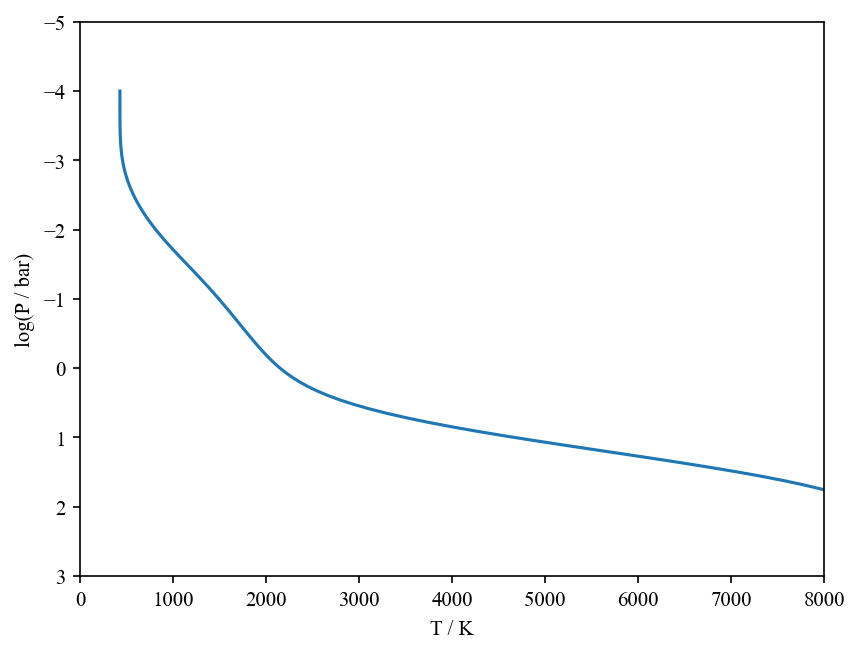

In [15]:
plt.rc('font',family='Times New Roman')
fig=plt.figure(dpi=150)
plt.axis([0., 8000.,3.0,-5.0])

logP = np.log10(args_instance.press)


plt.plot(Tprof,logP,label='proftype=4')

plt.ylabel(r'log(P / bar)')
plt.xlabel('T / K')